<a href="https://colab.research.google.com/github/LuciusMelillo09/DataScience/blob/main/Unit8/Copy_of_Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

Decision trees are essentially flow charts, diagramming out processes, however, decision trees have added restrictions, such as each node only being able to have one parent node, and there are also "root nodes" with no parents

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

Depth is the amouhnt of layers a decision tree can have, max number of nodes you can move to while only moving down the tree.

You can tell if a tree is too deep/not deep enough by looking at how many data points the dataset has, and if the model has enough data points to justify having more complexity, the higher depth of a decision tree you need.

**Task4:**

How are BART models similar and different from a decision tree?

BART models use decision trees, but they use many different decision trees, randomly altering each new tree based on the others

**Task5**:

Why would we use a BART model instead of a decision tree?

You would use BART instead of a decision tree because BART works better with more complex relationships (nonlinear), and it also does a good job to avoid overfitting

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [ ]:
!pip install pymc-bart
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import seaborn as sns
import graphviz as gv

In [ ]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [ ]:
x = penguins[['flipper_length', 'bill_depth', 'bill_length']]
y = penguins['body_mass']

with pm.Model() as model_penguins:
  mu = pmb.BART("mu", x.values, y.values, m=25)

  sigma = pm.HalfNormal("sigma", sigma=1)
  y_c = pm.Normal("y_c", mu=mu, sigma=sigma, observed=y.values)

  idata_penguins = pm.sample()
  pm.sample_posterior_predictive(idata_penguins, extend_inferencedata=True)

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

In [ ]:
posterior_mean = idata_penguins.posterior["mu"]

μ_hdi = az.hdi(ary=idata_penguins, group="posterior", var_names=["mu"], hdi_prob=0.74)

pps = az.extract(
    idata_penguins, group="posterior_predictive", var_names=["y_c"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


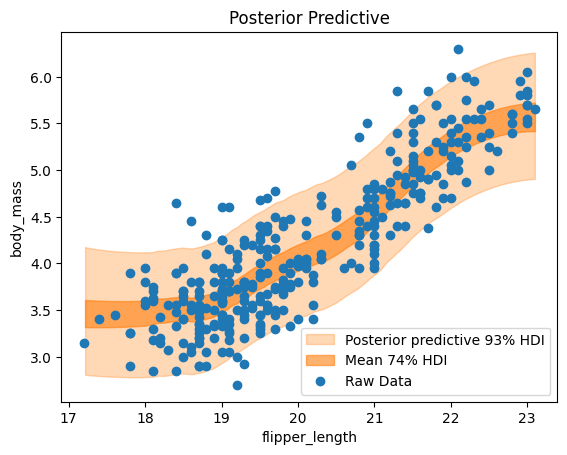

In [ ]:
idx = np.argsort(x.to_numpy()[:, 0])
fig, ax = plt.subplots()

az.plot_hdi(
    x=x.to_numpy()[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive 93% HDI"},
)

az.plot_hdi(
    x=x.to_numpy()[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean 74% HDI"},
)
ax.plot(penguins['flipper_length'], penguins["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper_length",
    ylabel="body_mass",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

I think it does capture the association between flipper length and body mass very well, as flipper length increases, so does body mass. I'm not sure if it's the best model to fit the trend of the data, to me it looks like just a simple linear model could work as well, but I'm not sure what would be better

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

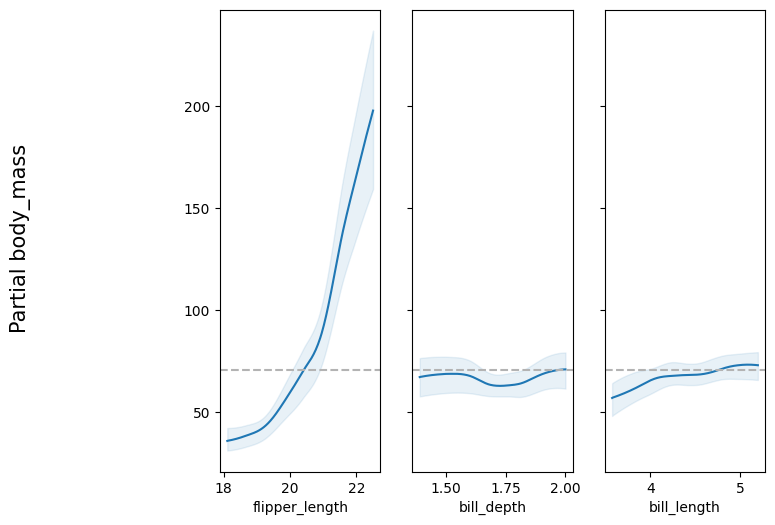

In [ ]:
pmb.plot_pdp(mu, x, y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

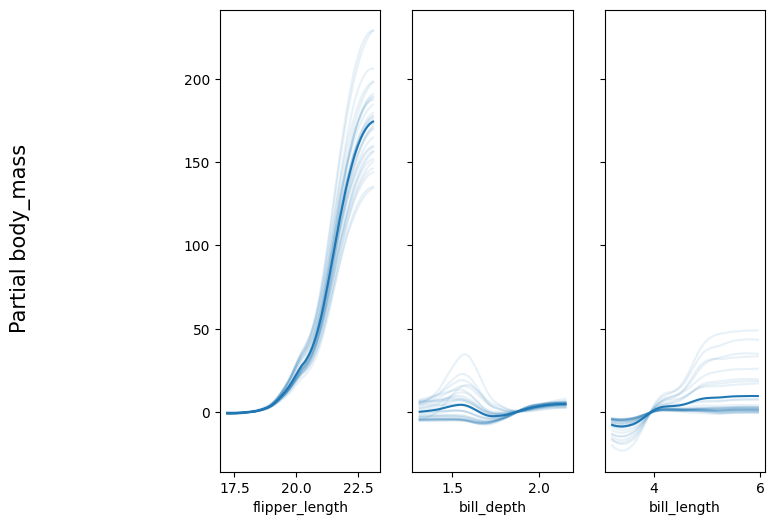

In [ ]:
pmb.plot_ice(mu, x, y, grid=(1, 5), func=np.exp, figsize = (12,6))

<Axes: ylabel='R²'>

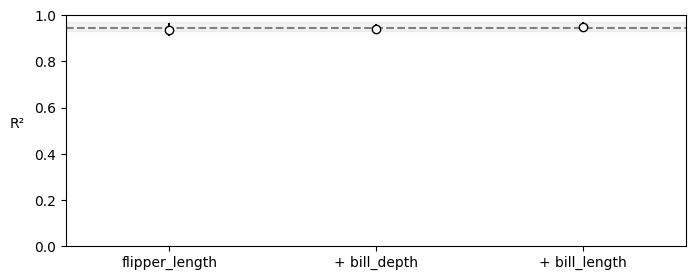

In [ ]:
vi_penguins = pmb.compute_variable_importance(idata_penguins, mu, x)
pmb.plot_variable_importance(vi_penguins)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

Looks like Flipper length is proportional to body mass, increases as the body mass increases. Bill Length is also fairly proportional, when it goes up, so does the body mass, however the bill depth has less clear of a correlation to body mass, perhaps the depth isn't correlated much with the body mass. Flipper length is clearly the best variable to use to predict body mass.